# Film Success Prediction (Capstone Final Project)
# Step 3: Modeling - Revenue Prediction (Regression)

## EDA and Feature Engineering complete - Next:

Predict **box office revenue** using features that are plausibly knowable before release:
- Budget (proxy for scale)
- Genre
- Runtime
- Release year
- Original language

## Evaluation metric

I will utilize:
- **RMSE** on log-transformed revenue (log1p) — robust for heavy-tailed revenue distributions
- **MAE** for easier interpretability
- **R²** as a standardized goodness-of-fit measure


In [10]:
# Core
import os
from pathlib import Path
import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Sklearn
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

PROJECT_DIR = Path(".").resolve()
DATA_DIR = PROJECT_DIR / "sample_data"
DATA_DIR.mkdir(exist_ok=True)


## 1) Load feature-engineered dataset generated from Step 2

In [11]:

df = pd.read_csv(DATA_DIR / "movies_feature_engineered.csv")
df.shape, df.head()


((3226, 19),
        id                                     title     budget     revenue  runtime  release_year  \
 0   19995                                    Avatar  237000000  2787965087    162.0        2009.0   
 1     285  Pirates of the Caribbean: At World's End  300000000   961000000    169.0        2007.0   
 2  206647                                   Spectre  245000000   880674609    148.0        2015.0   
 3   49026                     The Dark Knight Rises  250000000  1084939099    165.0        2012.0   
 4   49529                               John Carter  260000000   284139100    132.0        2012.0   
 
                                               genres original_language  popularity  vote_average  vote_count  \
 0  [{"id": 28, "name": "Action"}, {"id": 12, "nam...                en  150.437577           7.2       11800   
 1  [{"id": 12, "name": "Adventure"}, {"id": 14, "...                en  139.082615           6.9        4500   
 2  [{"id": 28, "name": "Action"},

## 2) Define targets and feature sets

In [12]:

# Target: revenue is extremely skewed, so use log1p(revenue)
df["y_log_revenue"] = np.log1p(df["revenue"])

# Feature set A: strictly pre-release-ish
features_prerelease = ["budget", "runtime", "release_year", "primary_genre", "original_language"]

# Feature set B: includes proxy engagement signals (may leak post-release effects)
features_with_signals = features_prerelease + ["popularity", "vote_average", "vote_count"]

X_a = df[features_prerelease].copy()
X_b = df[features_with_signals].copy()
y = df["y_log_revenue"].copy()

X_a.head()


,budget,runtime,release_year,primary_genre,original_language
0,237000000,162.0,2009.0,Action,en
1,300000000,169.0,2007.0,Adventure,en
2,245000000,148.0,2015.0,Action,en
3,250000000,165.0,2012.0,Action,en
4,260000000,132.0,2012.0,Action,en


## 3) Train/test split

In [13]:

X_train_a, X_test_a, y_train, y_test = train_test_split(X_a, y, test_size=0.2, random_state=42)
X_train_b, X_test_b, _, _ = train_test_split(X_b, y, test_size=0.2, random_state=42)

print("Train size:", len(X_train_a), "Test size:", len(X_test_a))


Train size: 2580 Test size: 646


## 4) Preprocessing pipeline

In [14]:

cat_cols_a = ["primary_genre", "original_language"]
num_cols_a = [c for c in features_prerelease if c not in cat_cols_a]

def make_preprocess(cat_cols, num_cols):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num_cols),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols),
        ],
        remainder="drop"
    )

preprocess_a = make_preprocess(cat_cols_a, num_cols_a)

cat_cols_b = ["primary_genre", "original_language"]
num_cols_b = [c for c in features_with_signals if c not in cat_cols_b]
preprocess_b = make_preprocess(cat_cols_b, num_cols_b)


## 5) Models + cross-validation

In [15]:

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42, max_iter=10000),
    "RandomForest": RandomForestRegressor(random_state=42, n_estimators=300),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)

def evaluate_models(X_train, y_train, preprocess):
    rows = []
    for name, model in models.items():
        pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
        scores = cross_validate(pipe, X_train, y_train, scoring=scoring, cv=cv, n_jobs=-1, error_score="raise")
        rows.append({
            "model": name,
            "RMSE (CV)": -scores["test_rmse"].mean(),
            "MAE (CV)": -scores["test_mae"].mean(),
            "R2 (CV)": scores["test_r2"].mean()
        })
    return pd.DataFrame(rows).sort_values("RMSE (CV)")

results_a = evaluate_models(X_train_a, y_train, preprocess_a)
results_a


,model,RMSE (CV),MAE (CV),R2 (CV)
4,GradientBoosting,1.499471,1.008887,0.462358
3,RandomForest,1.555643,1.056949,0.420355
1,Ridge,1.741224,1.143179,0.276984
0,LinearRegression,1.747052,1.146488,0.272134
2,Lasso,2.020616,1.390149,0.026013


### Compare: prerelease features vs prerelease + signals

In [16]:

results_b = evaluate_models(X_train_b, y_train, preprocess_b)
results_b


,model,RMSE (CV),MAE (CV),R2 (CV)
3,RandomForest,1.262226,0.794482,0.616125
4,GradientBoosting,1.265022,0.794313,0.614797
1,Ridge,1.706181,1.090275,0.304508
0,LinearRegression,1.711237,1.093743,0.300355
2,Lasso,2.020616,1.390149,0.026013


## 6) Hyperparameter tuning (GridSearchCV) for top candidates

In [17]:

# Tune Ridge (fast GridSearch) + RandomForest (fast RandomizedSearch)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from scipy.stats import randint

# Keep tuning quick on Colab
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Ridge is cheap, keep GridSearch
ridge_grid = {
    "model__alpha": [0.1, 1.0, 10.0, 50.0, 100.0]
}

def grid_search(model, param_grid, X_train, y_train, preprocess):
    pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
    gs = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    gs.fit(X_train, y_train)
    return gs

# RandomForest is expensive -> use RandomizedSearchCV
rf_dist = {
    "model__n_estimators": randint(150, 401),      # 150–400
    "model__max_depth": [None, 10, 15, 20],
    "model__min_samples_split": randint(2, 11),   # 2–10
    "model__min_samples_leaf": randint(1, 5),     # 1–4
}

def random_search(model, param_distributions, X_train, y_train, preprocess, n_iter=6):
    pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
    rs = RandomizedSearchCV(
        pipe,
        param_distributions=param_distributions,
        n_iter=n_iter,  # main speed knob
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
    rs.fit(X_train, y_train)
    return rs

gs_ridge_a = grid_search(Ridge(random_state=42), ridge_grid, X_train_a, y_train, preprocess_a)

rs_rf_a = random_search(RandomForestRegressor(random_state=42), rf_dist, X_train_a, y_train, preprocess_a, n_iter=6)

print("Best Ridge RMSE (CV):", -gs_ridge_a.best_score_, "Params:", gs_ridge_a.best_params_)
print("Best RF RMSE (CV):", -rs_rf_a.best_score_, "Params:", rs_rf_a.best_params_)


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Ridge RMSE (CV): 1.733966532450361 Params: {'model__alpha': 10.0}
Best RF RMSE (CV): 1.493666613779314 Params: {'model__max_depth': 15, 'model__min_samples_leaf': 4, 'model__min_samples_split': 9, 'model__n_estimators': 338}


## 7) Final evaluation on holdout test set

In [19]:

def eval_on_test(model, X_test, y_test):
    preds = model.predict(X_test)
    return {
        "RMSE (test)": rmse(y_test, preds),
        "MAE (test)": mean_absolute_error(y_test, preds),
        "R2 (test)": r2_score(y_test, preds)
    }, preds

ridge_metrics_a, ridge_preds_a = eval_on_test(gs_ridge_a.best_estimator_, X_test_a, y_test)
rf_metrics_a, rf_preds_a = eval_on_test(rs_rf_a.best_estimator_, X_test_a, y_test)

pd.DataFrame([{"model":"Ridge (tuned)", **ridge_metrics_a},
              {"model":"RandomForest (tuned)", **rf_metrics_a}]).sort_values("RMSE (test)")


,model,RMSE (test),MAE (test),R2 (test)
1,RandomForest (tuned),1.605337,1.054215,0.459246
0,Ridge (tuned),1.783911,1.134435,0.332250


### Plot: Predicted vs Actual (log revenue)

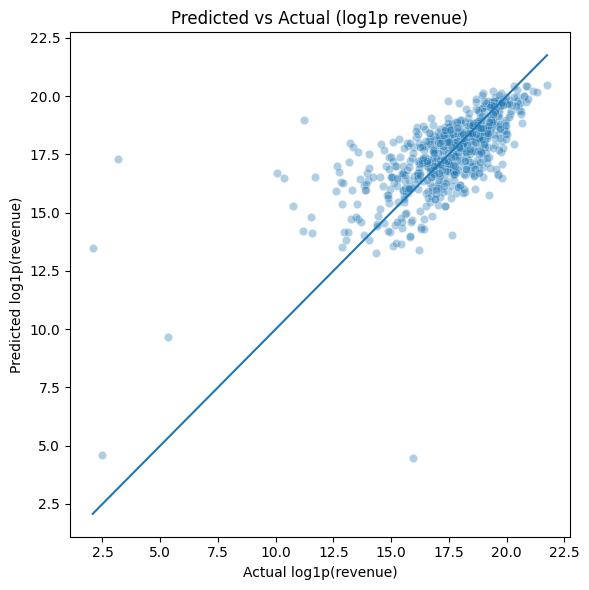

In [21]:

best_model = rs_rf_a.best_estimator_ if rf_metrics_a["RMSE (test)"] <= ridge_metrics_a["RMSE (test)"] else gs_ridge_a.best_estimator_
best_preds = rf_preds_a if best_model is rs_rf_a.best_estimator_ else ridge_preds_a

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=best_preds, alpha=0.35)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Predicted vs Actual (log1p revenue)")
plt.xlabel("Actual log1p(revenue)")
plt.ylabel("Predicted log1p(revenue)")
plt.tight_layout()
plt.show()


## 8) Model interpretation: permutation importance (top drivers)

,feature,importance_mean,importance_std
0,budget,0.535742,0.026625
1,runtime,0.061189,0.010688
3,primary_genre,0.049679,0.013211
4,original_language,0.007356,0.004124
2,release_year,0.002374,0.001452


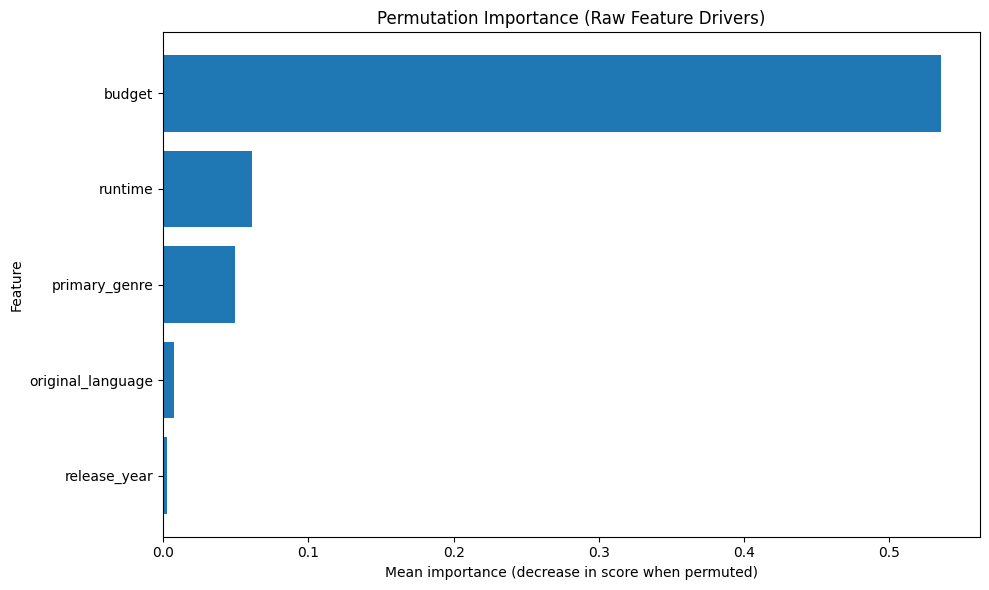

In [24]:

import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Use the final fitted PIPELINE (preprocess + model)
final_pipe = gs_ridge_a.best_estimator_

perm = permutation_importance(
    final_pipe,
    X_test_a,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Permutation importance is over RAW input columns
if hasattr(X_test_a, "columns"):
    feature_names = X_test_a.columns.to_list()
else:
    feature_names = [f"feature_{i}" for i in range(len(perm.importances_mean))]

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df)

# Plot top 15
topn = min(15, len(perm_df))
plt.figure(figsize=(10, 6))
plt.barh(
    perm_df["feature"].head(topn)[::-1],
    perm_df["importance_mean"].head(topn)[::-1]
)
plt.title("Permutation Importance (Raw Feature Drivers)")
plt.xlabel("Mean importance (decrease in score when permuted)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Interpretation (business-facing)

Typical expected patterns:
- **Budget** is one of the strongest predictors (scale matters), but it is not sufficient alone.
- **Genre** and **runtime** can meaningfully shift expected revenue.
- If I include **vote_count/popularity**, models often improve substantially — but these may be *post-release* entities (marketing + distribution reach).
